In [1]:
import warnings
from json import dumps
from pickle import Pickler
from shutil import rmtree
from pathlib import Path
from typing import Literal
from gzip import open as gz_open
from joblib import Parallel, delayed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, minmax_scale
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer
from sklearn.metrics import average_precision_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from statsmodels.stats.outliers_influence import variance_inflation_factor


RANDOM_STATE = 12345
VIF_THRESHOLD = 10.0

# Dados

In [2]:
def prepare_experiment(
    which: Literal["full", "iot", "control", "infra"],
    target: Literal["binary", "grouped", "all"],
    overwrite: bool = False,
):
    experiment = {}
    dataset_path = Path("../datasense/dataset/")
    for split in ["train", "test"]:
        split_data = dataset_path / f"datasense_{which}_{split}_1sec.parquet"
        split_data = pd.read_parquet(split_data)
        if target == "binary":
            y_split = split_data["label1"]
        elif target == "grouped":
            y_split = split_data["label2"]
        else:
            y_split = split_data["label4"]
        experiment[split] = (split_data, y_split)
    experiment["classes"] = sorted(experiment["train"][1].unique())
    experiment["sample_weight"] = compute_sample_weight(
        class_weight="balanced",
        y=experiment["train"][0]["label_extended"],
    )
    log1p_transformer = FunctionTransformer(np.log1p, feature_names_out="one-to-one")
    number_selector = make_column_selector(dtype_include="number")
    bool_selector = make_column_selector(dtype_include="bool")
    if which == "full":
        experiment["normalizer"] = make_column_transformer(
            (make_pipeline(log1p_transformer, MinMaxScaler()), number_selector),
            (OneHotEncoder(sparse_output=False), ["device_type"]),
            ("passthrough", bool_selector),
            verbose_feature_names_out=False,
        )
    else:
        experiment["normalizer"] = make_column_transformer(
            (make_pipeline(log1p_transformer, MinMaxScaler()), number_selector),
            ("passthrough", bool_selector),
            verbose_feature_names_out=False,
        )
    results_dir = Path("results")
    results_dir /= f"logistic_regression_{which}_{target}"
    if results_dir.is_dir():
        if overwrite:
            rmtree(results_dir, ignore_errors=True)
        else:
            raise RuntimeError("Experiment already executed and overwrite set to False")
    results_dir.mkdir(exist_ok=True, parents=True)
    cache_dir = results_dir / ".cache"
    cache_dir.mkdir()
    experiment["results_dir"] = results_dir
    experiment["cache_dir"] = str(cache_dir)
    return experiment

In [3]:
experiment = prepare_experiment(which="full", target="binary", overwrite=True)

X_train, y_train = experiment["train"]
sample_weight = experiment["sample_weight"]
class_names = experiment["classes"]
num_classes = len(class_names)
X_test, y_test = experiment["test"]
results_dir = experiment["results_dir"]
cache_dir = experiment["cache_dir"]

# Colinear features removal

In [4]:
def _vif(data, i):
    with warnings.catch_warnings():
        warnings.simplefilter(action="ignore", category=RuntimeWarning)
        return variance_inflation_factor(data, i)


def get_vif_features_out(
    data: np.ndarray,
    feature_names: list[str],
    vif_threshold: float = 5.0,
    num_samples: int = 30000,
) -> pd.Series:
    feature_names = list(feature_names)
    rng = np.random.default_rng(seed=RANDOM_STATE)
    sample_idxs = rng.choice(data.shape[0], size=num_samples)
    data_sample = np.ones((num_samples, data.shape[1] + 1), dtype=float)
    data_sample[:, :-1] = data[sample_idxs]
    to_remove = {"index": [], "data": []}
    while True:
        vifs = np.array(
            Parallel(n_jobs=6)(
                delayed(_vif)(data_sample, i)
                for i in range(data_sample.shape[1] - 1)
            )
        )
        max_vif_col = vifs.argmax()
        if not vifs[max_vif_col] >= vif_threshold:
            break
        feature_name_out = feature_names.pop(max_vif_col)
        to_remove["data"].append(vifs[max_vif_col])
        to_remove["index"].append(feature_name_out)
        data_sample = np.delete(data_sample, max_vif_col, axis=1)
    return pd.Series(**to_remove, name="vif")

In [5]:
X_train_norm = experiment["normalizer"].fit_transform(X_train)
feature_names_out = experiment["normalizer"].get_feature_names_out().tolist()

In [6]:
vif_removed = results_dir.parent / "vif_removed_features.csv"

# NOTE: This is a very time consuming step.
# Results are saved to avoid recomputing it every time.
if vif_removed.is_file():
    print("Already computed. Reading...")
    vif_out_features = pd.read_csv(vif_removed, index_col="feature")
    vif_out_features = vif_out_features["vif"]
else:
    vif_out_features = get_vif_features_out(X_train_norm, feature_names_out)
    vif_out_features.to_csv(vif_removed, index=True, index_label="feature")

del X_train_norm

vif_out_features

Already computed. Reading...


feature
network_macs_dst_count                       inf
device_type_control                          inf
network_header-length_min           8.248370e+06
network_header-length_avg           6.950146e+05
network_mss_max                     4.593239e+04
                                        ...     
network_packets_src_count           6.378289e+00
network_protocols_src_has_telnet    5.903173e+00
network_ports_src_has_80            5.661157e+00
network_fragmented-packets          5.615247e+00
network_ports_dst_has_554           5.433103e+00
Name: vif, Length: 62, dtype: float64

In [7]:
vif_thres = max(5.0, VIF_THRESHOLD)

vif_remove_indexes = [
    feature_names_out.index(ft)
    for ft in vif_out_features.index
    if vif_out_features[ft] >= vif_thres
]

padding = max(map(lambda x: len(feature_names_out[x]), vif_remove_indexes))
print(f"REMOVED FEATURES (VIF >= {vif_thres:.2f}):")
print("\n".join(
    "{0:02d} - {1} : {2:.2f}".format(
        i,
        feature_names_out[idx].rjust(padding),
        vif_out_features[feature_names_out[idx]],
    )
    for i, idx in enumerate(vif_remove_indexes, start=1)
))

REMOVED FEATURES (VIF >= 10.00):
01 -               network_macs_dst_count : inf
02 -                  device_type_control : inf
03 -            network_header-length_min : 8248369.90
04 -            network_header-length_avg : 695014.59
05 -                      network_mss_max : 45932.39
06 -                      network_mss_avg : 7074.41
07 -          network_fragmentation-score : 7073.37
08 -                network_ip-length_max : 1024.07
09 -            network_packets_all_count : 912.87
10 -            network_header-length_max : 790.92
11 -                network_ip-length_avg : 611.50
12 -                      network_ttl_avg : 427.78
13 -               network_macs_src_count : 310.81
14 -                      network_ttl_max : 257.20
15 -              network_packet-size_avg : 235.61
16 -                network_tcp-flags_avg : 199.20
17 -              network_window-size_max : 192.50
18 -              network_ports_all_count : 187.75
19 -              network_packet-size_max :

# Experiment

## Training pipe

In [8]:
transformer = make_pipeline(
    experiment["normalizer"],
    make_column_transformer(
        ("drop", vif_remove_indexes),
        remainder="passthrough",
        verbose_feature_names_out=False,
    ),
    memory=cache_dir,
)

model = LogisticRegression(
    max_iter=4000,
    l1_ratio=0.0,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)

In [9]:
train_pipe = Pipeline(
    steps=[("transformer", transformer), ("model", model)],
    memory=cache_dir,
    verbose=False,
)

## Grid seach cross-validation

In [10]:
C_range = [10**i for i in range(-5, 5)]
C_range.append(np.inf)

param_grid = {"model__C": C_range}

In [11]:
if num_classes < 3:
    # Average Precision is threshold independent
    scoring = make_scorer(
        average_precision_score,
        response_method="decision_function",
        pos_label="attack",
    )
else:
    # In multiclass classification, thresholding isn't important
    # Just pick the most probable class
    scoring = "f1_macro"

In [12]:
grid = GridSearchCV(
    estimator=train_pipe,
    param_grid=param_grid,
    scoring=scoring,
    n_jobs=4,
    refit=True,
    cv=4,
    verbose=3,
)

with warnings.catch_warnings():
    warnings.filterwarnings(action="ignore", message=r"^Setting penalty=None will ignore")
    warnings.filterwarnings(action="ignore", message=r"Persisting input arguments took")
    grid.fit(X_train, y_train, model__sample_weight=sample_weight)

trained_pipe = grid.best_estimator_
trained_model = trained_pipe["model"]

Fitting 4 folds for each of 11 candidates, totalling 44 fits
[CV 3/4] END ....................model__C=1e-05;, score=0.870 total time=   3.2s
[CV 4/4] END ....................model__C=1e-05;, score=0.872 total time=   3.3s
[CV 2/4] END ....................model__C=1e-05;, score=0.874 total time=   3.4s
[CV 1/4] END ....................model__C=1e-05;, score=0.870 total time=   3.5s
[CV 1/4] END ...................model__C=0.0001;, score=0.876 total time=   1.3s
[CV 2/4] END ...................model__C=0.0001;, score=0.879 total time=   1.4s
[CV 3/4] END ...................model__C=0.0001;, score=0.875 total time=   1.4s
[CV 4/4] END ...................model__C=0.0001;, score=0.878 total time=   1.5s
[CV 1/4] END ....................model__C=0.001;, score=0.892 total time=   1.4s
[CV 3/4] END ....................model__C=0.001;, score=0.892 total time=   1.7s
[CV 2/4] END ....................model__C=0.001;, score=0.895 total time=   1.8s
[CV 4/4] END ....................model__C=0.001;

## Cross-validation results

In [13]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results.sort_values(by="rank_test_score", inplace=True)
cv_results.to_csv(results_dir / "train_cv_results.csv", index=False)

cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
4,1.396237,0.229220,0.490602,0.056692,0.1000,{'model__C': 0.1},0.904960,0.904612,0.907103,0.907842,0.906129,0.001374,1
5,2.108631,0.045882,0.495231,0.047717,1.0000,{'model__C': 1},0.903250,0.904710,0.905773,0.906949,0.905170,0.001363,2
6,2.325309,0.119333,0.193410,0.547844,10.0000,{'model__C': 10},0.904073,0.904308,0.905330,0.906606,0.905079,0.001000,3
10,2.479512,0.249996,0.480986,0.230585,inf,{'model__C': inf},0.902954,0.903788,0.905214,0.906407,0.904591,0.001324,4
9,2.315868,0.090634,0.545849,0.079514,10000.0000,{'model__C': 10000},0.902955,0.903765,0.905214,0.906407,0.904585,0.001327,5
7,1.158362,0.562545,0.586899,0.099249,100.0000,{'model__C': 100},0.902952,0.903681,0.905229,0.906406,0.904567,0.001343,6
8,2.344803,0.159397,0.466342,0.045387,1000.0000,{'model__C': 1000},0.902957,0.903624,0.905214,0.906407,0.904550,0.001350,7
3,1.340042,0.249540,0.450185,0.028578,0.0100,{'model__C': 0.01},0.903251,0.902533,0.903019,0.905735,0.903635,0.001240,8
2,1.233159,0.221218,0.470442,0.080828,0.0010,{'model__C': 0.001},0.892009,0.894991,0.892325,0.894928,0.893563,0.001401,9
1,0.947689,0.154752,0.473662,0.109437,0.0001,{'model__C': 0.0001},0.875558,0.879244,0.875486,0.878026,0.877079,0.001615,10


## Feature importance

In [14]:
importances = np.abs(trained_model.coef_).mean(axis=0).tolist()
feature_names = [
    ft for i, ft in enumerate(feature_names_out)
    if i not in vif_remove_indexes
]
importances.extend([0.0] * len(vif_remove_indexes))
feature_names.extend([feature_names_out[idx] for idx in vif_remove_indexes])
feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
})
feature_importances.sort_values(
    by="importance", ascending=False,
    ignore_index=True, inplace=True,
)
feature_importances["importance_norm"] = minmax_scale(feature_importances["importance"])
feature_importances.to_csv(results_dir / "feature_importances.csv", index=False)

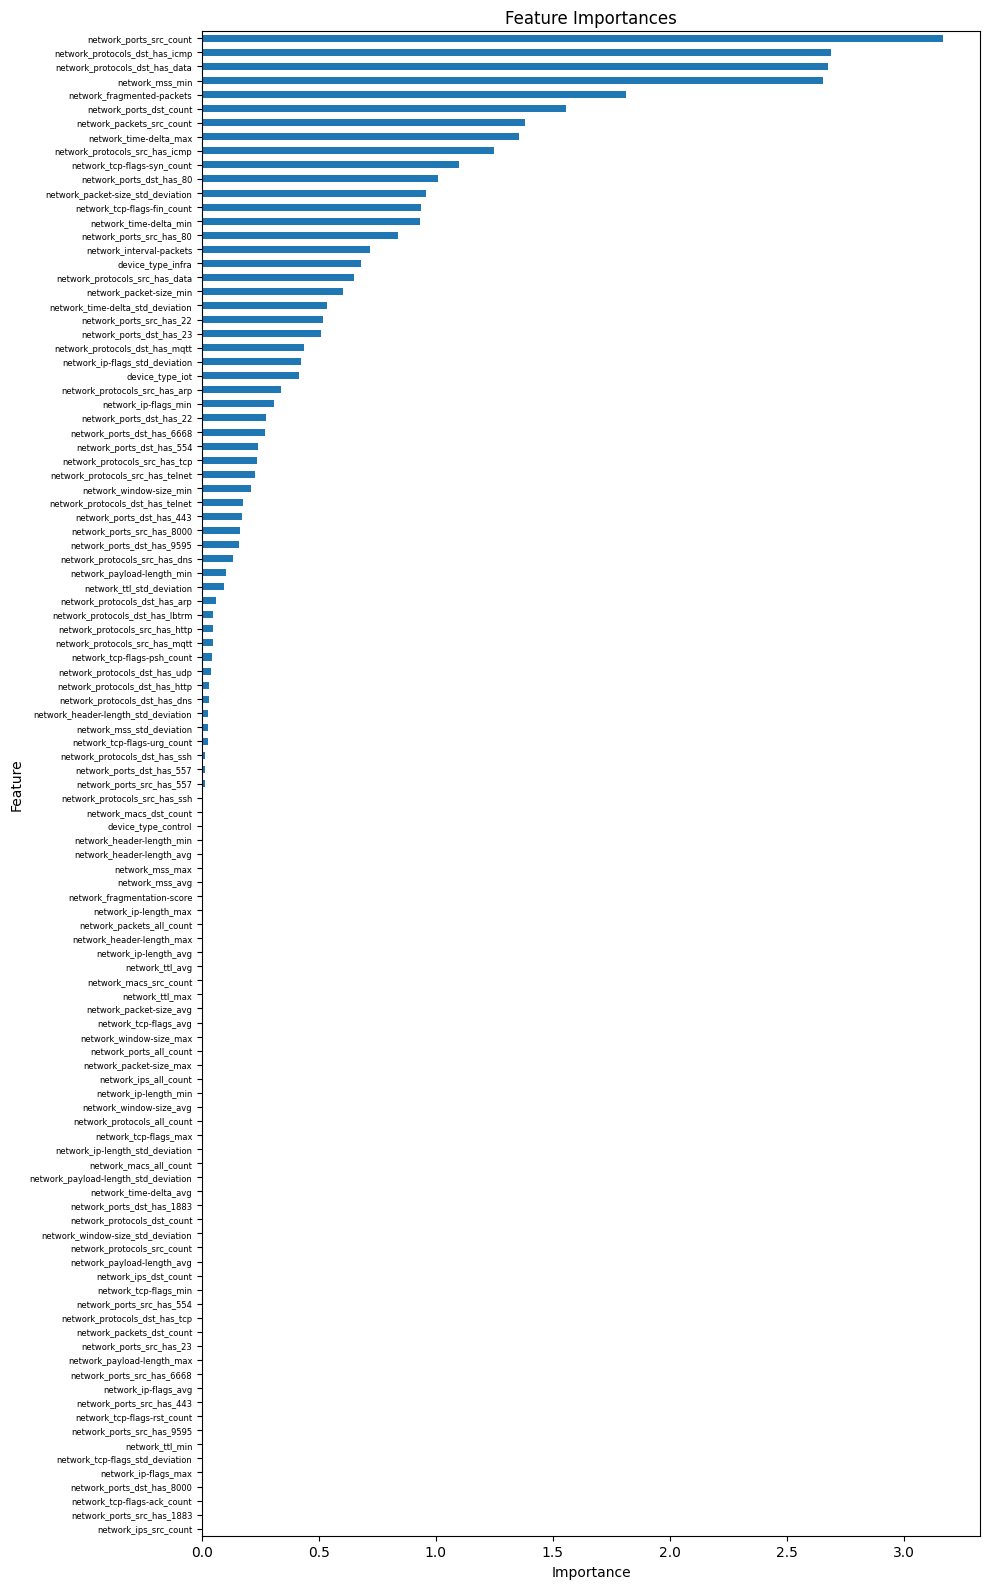

In [15]:
fig, ax = plt.subplots(figsize=(10, 16))

feature_importances["importance"].plot(kind="barh", ax=ax)

ax.invert_yaxis()
ax.set_yticks(
    ticks=range(feature_importances.shape[0]),
    labels=feature_importances["feature"],
    fontsize=6,
)
ax.set_title("Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(results_dir / "feature_importances.png", dpi=300)
plt.show()

# Model evaluations

## Train-split evaluations

In [16]:
y_proba = trained_pipe.predict_proba(X_train)

train_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

train_results.to_parquet(
    results_dir / "train_predict_proba.parquet",
    index=False,
    compression="gzip",
)

## Test-split evaluations

In [17]:
y_proba = trained_pipe.predict_proba(X_test)

test_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

test_results.to_parquet(
    results_dir / "test_predict_proba.parquet",
    index=False,
    compression="gzip",
)

# Model summary and persistency

## Model persistency

In [18]:
pipe_persist_path = results_dir / "pipe.pickle.gz"

with gz_open(pipe_persist_path, mode="wb") as pf:
    Pickler(pf, protocol=5).dump(trained_pipe)

## Model summary

In [19]:
model_summary = {
    "best_parameters": grid.best_params_,
    "all_parameters": trained_model.get_params(),
}

model_summary = dumps(model_summary, indent=2)
(results_dir / "model_summary.json").write_text(model_summary)
print("MODEL SUMMARY:", model_summary, sep="\n")

MODEL SUMMARY:
{
  "best_parameters": {
    "model__C": 0.1
  },
  "all_parameters": {
    "C": 0.1,
    "class_weight": null,
    "dual": false,
    "fit_intercept": true,
    "intercept_scaling": 1,
    "l1_ratio": 0.0,
    "max_iter": 4000,
    "n_jobs": null,
    "penalty": "deprecated",
    "random_state": 12345,
    "solver": "lbfgs",
    "tol": 0.0001,
    "verbose": 0,
    "warm_start": false
  }
}
